<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
  Residual Distribution Analysis 
</p>

#### Core & Data Libraries

In [1]:
# Core & Visualization
import os

# Set BLAS thread caps before importing NumPy/SciPy/sklearn in this kernel.
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_MAX_THREADS", "1")

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D
from IPython.display import display

# ML & Stats
from sklearn.mixture import GaussianMixture
from scipy.stats import kstest, norm, t, skewnorm, cauchy, skew, kurtosis
from scipy.interpolate import interp1d

warnings.filterwarnings("ignore")

#### Load OOF residuals + discover optional columns

In [2]:
# Load residuals
RESID_PATH = "Residuals/residuals_SVR_oof.csv"
df_res = pd.read_csv(RESID_PATH)

# Detect columns
res_candidates = ["resid_db", "residuals", "resid", "error"]
res_col = next((c for c in res_candidates if c in df_res.columns), None)
if res_col is None:
    raise KeyError(f"No residual column found; tried {res_candidates}")

col_dev = next((c for c in ["device_id", "device", "ed", "ED", "node", "Device", "Node"] if c in df_res.columns), None)
col_los = next((c for c in ["los", "LoS", "LOS", "is_los"] if c in df_res.columns), None)

# Core residual array. Finite filtering happens in the fitting cell so all downstream arrays align.
residuals = df_res[res_col].astype(float).to_numpy()
n = residuals.size

# LoS/NLoS labels; ED0 treated as LoS when no explicit LoS column exists.
LOS_DEVICES = {"ED0"}

if col_los is not None:
    los_raw = df_res[col_los].astype(str).str.strip().str.upper()
    los_series = pd.Series(
        np.where(los_raw.isin(["LOS", "LINE_OF_SIGHT", "TRUE", "1", "YES"]), "LOS", "NLOS"),
        index=df_res.index,
        name="los",
    )
elif col_dev is not None:
    dev_norm = df_res[col_dev].astype(str).str.strip().str.upper()
    los_set = {d.strip().upper() for d in LOS_DEVICES}
    los_series = pd.Series(np.where(dev_norm.isin(los_set), "LOS", "NLOS"), index=df_res.index, name="los")
else:
    los_series = None

if los_series is not None:
    df_res["los"] = los_series
    print("LoS counts:", int((los_series == "LOS").sum()), "| NLoS counts:", int((los_series == "NLOS").sum()))

print("Detected ->", f"residual={res_col}, device={col_dev}, los={col_los}")
print(f"Loaded residuals: n={n:,d}")

LoS counts: 84895 | NLoS counts: 414196
Detected -> residual=resid_db, device=device_id, los=None
Loaded residuals: n=499,091


**Residual diagnostics (normality + tail-heaviness + weak autocorrelation).**  
Omnibus and Jarque–Bera test Normality; skewness/kurtosis quantify tail behavior; Durbin–Watson checks serial correlation (residuals to be in chronological order for DW to reflect time dependence).

In [3]:
#  Normality + tail + autocorrelation check

res = np.asarray(residuals, dtype=float)
res = res[np.isfinite(res)]

def pfmt(p):
    return "<1e-16" if p < 1e-16 else f"{p:.2e}"

# Prefer statsmodels (matches "Omnibus" and DW used in regression diagnostics); fall back to SciPy if needed.
try:
    from statsmodels.stats.stattools import omni_normtest, jarque_bera, durbin_watson
    omni_stat, omni_p = omni_normtest(res)        # Omnibus (D'Agostino–Pearson)
    jb_stat, jb_p, _, _ = jarque_bera(res)        # Jarque–Bera
    dw = durbin_watson(res)                       # Durbin–Watson (order-sensitive)
except Exception:
    from scipy.stats import normaltest, jarque_bera
    omni_stat, omni_p = normaltest(res)           # D'Agostino–Pearson K^2 (Omnibus-style)
    jb = jarque_bera(res)
    jb_stat, jb_p = float(jb.statistic), float(jb.pvalue)
    dw = np.sum(np.diff(res)**2) / np.sum(res**2) # DW equivalent

sk = skew(res)
ek = kurtosis(res, fisher=True)                   # excess kurtosis

print(f"N = {res.size:,d}")
print(f"Omnibus (D'Agostino): stat = {omni_stat:.2f}, p = {pfmt(omni_p)}")
print(f"Jarque–Bera         : stat = {jb_stat:.2f}, p = {pfmt(jb_p)}")
print(f"Skewness            : {sk:.3f}  (right tail if > 0)")
print(f"Excess kurtosis     : {ek:.3f}  (heavy tails if > 0)")
print(f"Durbin–Watson       : {dw:.3f}  (≈ 2 implies weak autocorrelation)")

N = 499,091
Omnibus (D'Agostino): stat = 51472.80, p = <1e-16
Jarque–Bera         : stat = 338514.68, p = <1e-16
Skewness            : 0.272  (right tail if > 0)
Excess kurtosis     : 3.998  (heavy tails if > 0)
Durbin–Watson       : 1.657  (≈ 2 implies weak autocorrelation)


#### Fit Distributions (PARAMETRIC) 

In [4]:
# Fit distributions and GMM candidates once.
# Downstream cells reuse: res, residuals_array, sorted_residuals, probabilities,
# gmm_models, gmm_diag_df, best_gmm, gmm_cdf, gmm_display_names, and gmm_table_names.

res = np.asarray(residuals, dtype=float)
res = res[np.isfinite(res)]
n = res.size
residuals_array = res.reshape(-1, 1)
sorted_residuals = np.sort(res)
probabilities = (np.arange(1, n + 1) - 0.5) / n

# 1. Normal distribution
normal_params = norm.fit(res)
loc_norm, scale_norm = normal_params
normal_dist = norm(loc=loc_norm, scale=scale_norm)

# 2. Skew-normal distribution
skew_params = skewnorm.fit(res)
shape_sn, loc_sn, scale_sn = skew_params
skew_dist = skewnorm(shape_sn, loc=loc_sn, scale=scale_sn)

# 3. Cauchy distribution
cauchy_params = cauchy.fit(res)
cauchy_dist = cauchy(*cauchy_params)

# 4. Student's t distribution
t_params = t.fit(res)
df_t, loc_t, scale_t = t_params
t_dist = t(df=df_t, loc=loc_t, scale=scale_t)

# 5. GMM candidates, K = 1,...,5
gmm_display_names = {1: "Gaussian", 2: "2-comp. GMM", 3: "3-comp. GMM",  4: "4-comp. GMM", 5: "5-comp. GMM",}

gmm_table_names = {1: "Gaussian", 2: "GMM(K=2)", 3: "GMM(K=3)", 4: "GMM(K=4)", 5: "GMM(K=5)",}

gmm_models = [
    GaussianMixture(n_components=k, random_state=42).fit(residuals_array)
    for k in range(1, 6)
]

# Robust GMM CDF helper, shared by KS tests, tail metrics, and Q-Q plots.
def gmm_cdf(x, gmm_model):
    x = np.asarray(x, dtype=float)
    means = gmm_model.means_.ravel()
    covs = gmm_model.covariances_

    if covs.ndim == 3:
        covs = covs[:, 0, 0]
    elif covs.ndim == 2:
        covs = covs[:, 0]

    stds = np.sqrt(covs)
    weights = gmm_model.weights_.ravel()

    cdf = np.zeros_like(x, dtype=float)
    for w, m, s in zip(weights, means, stds):
        cdf += w * norm.cdf(x, loc=m, scale=s)
    return cdf

def compute_aic_bic(log_likelihood, num_params, num_samples):
    aic = 2 * num_params - 2 * log_likelihood
    bic = num_params * np.log(num_samples) - 2 * log_likelihood
    return aic, bic

def finite_loglik(pdf_values):
    pdf_values = np.asarray(pdf_values, dtype=float)
    return float(np.sum(np.log(np.clip(pdf_values, np.finfo(float).tiny, None))))

def gmm_num_params(k):
    # Univariate GMM: (k - 1) weights + k means + k variances.
    return 3 * k - 1

# GMM diagnostics for every candidate model.
gmm_diagnostics = []
for k, gmm_k in enumerate(gmm_models, start=1):
    loglik_k = float(np.sum(gmm_k.score_samples(residuals_array)))
    aic_k, bic_k = compute_aic_bic(loglik_k, gmm_num_params(k), n)
    ks_k = kstest(res, lambda x, model=gmm_k: gmm_cdf(x, model))

    gmm_diagnostics.append({
        "GMM Components": k,
        "Model Label": gmm_display_names[k],
        "Log-Likelihood": loglik_k,
        "AIC": aic_k,
        "BIC": bic_k,
        "KS Statistic": ks_k.statistic,
        "KS p-value": ks_k.pvalue,
    })

gmm_diag_df = pd.DataFrame(gmm_diagnostics)
best_gmm_row = gmm_diag_df.loc[gmm_diag_df["BIC"].idxmin()]
best_gmm_components = int(best_gmm_row["GMM Components"])
best_gmm = gmm_models[best_gmm_components - 1]
best_gmm_display_name = gmm_display_names[best_gmm_components]
best_gmm_table_name = gmm_table_names[best_gmm_components]

print(
    f"\nSelected {best_gmm_display_name} based on lowest BIC: "
    f"{best_gmm_row['BIC']:.2f}"
)

# Global distribution diagnostics. The GMM row uses the BIC-selected model.
loglik_norm = finite_loglik(normal_dist.pdf(res))
aic_norm, bic_norm = compute_aic_bic(loglik_norm, 2, n)
ks_norm = kstest(res, normal_dist.cdf)

loglik_sn = finite_loglik(skew_dist.pdf(res))
aic_sn, bic_sn = compute_aic_bic(loglik_sn, 3, n)
ks_sn = kstest(res, skew_dist.cdf)

loglik_cauchy = finite_loglik(cauchy_dist.pdf(res))
aic_cauchy, bic_cauchy = compute_aic_bic(loglik_cauchy, 2, n)
ks_cauchy = kstest(res, cauchy_dist.cdf)

loglik_t = finite_loglik(t_dist.pdf(res))
aic_t, bic_t = compute_aic_bic(loglik_t, 3, n)
ks_t = kstest(res, t_dist.cdf)

loglik_gmm = float(best_gmm_row["Log-Likelihood"])
aic_gmm = float(best_gmm_row["AIC"])
bic_gmm = float(best_gmm_row["BIC"])
ks_gmm = kstest(res, lambda x: gmm_cdf(x, best_gmm))

diagnostics = pd.DataFrame({
    "Distribution": [
        "Normal",
        "Skew-Normal",
        f"Best GMM ({best_gmm_display_name})",
        "Cauchy",
        "t-Distribution",
    ],
    "Log-Likelihood": [loglik_norm, loglik_sn, loglik_gmm, loglik_cauchy, loglik_t],
    "AIC": [aic_norm, aic_sn, aic_gmm, aic_cauchy, aic_t],
    "BIC": [bic_norm, bic_sn, bic_gmm, bic_cauchy, bic_t],
    "KS Test Statistic": [ks_norm.statistic, ks_sn.statistic, ks_gmm.statistic, ks_cauchy.statistic, ks_t.statistic,],
    "KS Test p-value": [ks_norm.pvalue, ks_sn.pvalue, ks_gmm.pvalue,  ks_cauchy.pvalue, ks_t.pvalue,],
})

print("\nDiagnostics Table:")
display(
    diagnostics.round({
        "Log-Likelihood": 2,
        "AIC": 2,
        "BIC": 2,
        "KS Test Statistic": 4,
        "KS Test p-value": 4,
    })
)

best_fit = diagnostics.loc[diagnostics["KS Test Statistic"].idxmin()]
print(f"\nBest Fit (Based on KS Test Statistic): {best_fit['Distribution']}\n")


Selected 3-comp. GMM based on lowest BIC: 3232351.16

Diagnostics Table:


,Distribution,Log-Likelihood,AIC,BIC,KS Test Statistic,KS Test p-value
0,Normal,-1632813.98,3265631.97,3265654.21,0.0404,0.0
1,Skew-Normal,-1628477.49,3256960.98,3256994.34,0.0300,0.0
2,Best GMM (3-comp. GMM),-1616123.10,3232262.20,3232351.16,0.0065,0.0
3,Cauchy,-1684314.23,3368632.45,3368654.70,0.0752,0.0
4,t-Distribution,-1617615.00,3235235.99,3235269.36,0.0156,0.0



Best Fit (Based on KS Test Statistic): Best GMM (3-comp. GMM)



#### GMM Diagnostics (1–5 components)

In [5]:
# GMM diagnostics table from the models fitted in the distribution-fit cell.

print("\nGMM Diagnostics (K = 1 to 5)")
display(
    gmm_diag_df.round({
        "Log-Likelihood": 2,
        "AIC": 2,
        "BIC": 2,
        "KS Statistic": 4,
        "KS p-value": 4,
    })
)

print(f"\nBest GMM model based on lowest BIC: {best_gmm_display_name}\n")


GMM Diagnostics (K = 1 to 5)


,GMM Components,Model Label,Log-Likelihood,AIC,BIC,KS Statistic,KS p-value
0,1,Gaussian,-1632813.98,3265631.97,3265654.21,0.0404,0.0
1,2,2-comp. GMM,-1617162.76,3234335.52,3234391.13,0.0073,0.0
2,3,3-comp. GMM,-1616123.10,3232262.20,3232351.16,0.0065,0.0
3,4,4-comp. GMM,-1621509.45,3243040.90,3243163.23,0.0083,0.0
4,5,5-comp. GMM,-1619696.82,3239421.64,3239577.33,0.0071,0.0



Best GMM model based on lowest BIC: 3-comp. GMM



In [6]:
# Q-Q tail error metrics for fitted parametric distributions and all GMM candidates.

TAIL_PROB_LOW = 0.05
TAIL_PROB_HIGH = 0.95
N_QQ_TAIL_POINTS = 200
PPF_GRID_SIZE = 50_000

QQ_LINEWIDTH = 2
QQ_LEGEND_MARKER_SIZE = 7
QQ_TAIL_BOX_POS = (0.08, 0.76)
SUBPLOT_LABELS = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]

p_low = np.linspace(0.001, TAIL_PROB_LOW, N_QQ_TAIL_POINTS)
p_high = np.linspace(TAIL_PROB_HIGH, 0.999, N_QQ_TAIL_POINTS)

def qq_tail_metrics(empirical_q, model_q):
    err = empirical_q - model_q
    return {
        "tail_rmse": float(np.sqrt(np.mean(err ** 2))),
        "tail_mae": float(np.mean(np.abs(err))),
        "tail_bias": float(np.mean(err)),
        "tail_max_abs": float(np.max(np.abs(err))),
    }

def gmm_ppf_from_existing_cdf(p_grid, gmm_model, reference_values):
    ref = np.asarray(reference_values, dtype=float)

    means = gmm_model.means_.ravel()
    covs = gmm_model.covariances_

    if covs.ndim == 3:
        covs = covs[:, 0, 0]
    elif covs.ndim == 2:
        covs = covs[:, 0]

    stds = np.sqrt(covs)

    lo = min(ref.min(), np.min(means - 8 * stds))
    hi = max(ref.max(), np.max(means + 8 * stds))

    x_grid = np.linspace(lo, hi, PPF_GRID_SIZE)
    cdf_grid = np.maximum.accumulate(gmm_cdf(x_grid, gmm_model))

    unique_cdf, unique_idx = np.unique(cdf_grid, return_index=True)
    unique_x = x_grid[unique_idx]

    return np.interp(p_grid, unique_cdf, unique_x)

def qq_legend(ax, title, color):
    handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            markerfacecolor=color,
            markeredgecolor="k",
            markersize=QQ_LEGEND_MARKER_SIZE,
            label="Empirical residual quantiles",
        ),
        Line2D(
            [0], [0],
            color="r",
            linestyle="--",
            linewidth=QQ_LINEWIDTH,
            label=r"Reference ($y=x$)",
        ),
    ]
    leg = ax.legend(handles=handles, loc="lower right", frameon=False, title=rf"{title} fit")
    leg.get_title().set_fontstyle("italic")
    leg.get_title().set_fontweight("bold")

def add_tail_error_text(ax, table_name, tail_error_table, pos=QQ_TAIL_BOX_POS):
    row = tail_error_table[
        (tail_error_table["distribution"] == table_name)
        & (tail_error_table["tail"] == "both")
    ]

    if row.empty:
        return

    row = row.iloc[0]
    txt = f"Tail RMSE = {row['tail_rmse']:.2f} dB\nBias = {row['tail_bias']:.2f} dB"

    ax.text(
        pos[0], pos[1], txt,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.5", alpha=0.85),
        zorder=10,
    )

fitted_distributions = {
    "Normal": normal_dist,
    "SkewNormal": skew_dist,
    "Cauchy": cauchy_dist,
    "StudentT": t_dist,
}

tail_error_rows = []

for tail_name, p_grid in {
    "lower": p_low,
    "upper": p_high,
    "both": np.r_[p_low, p_high],
}.items():

    empirical_q = np.quantile(res, p_grid)

    for dist_name, dist_obj in fitted_distributions.items():
        model_q = dist_obj.ppf(p_grid)
        metrics = qq_tail_metrics(empirical_q, model_q)

        tail_error_rows.append({
            "distribution": dist_name,
            "tail": tail_name,
            "p_min": float(np.min(p_grid)),
            "p_max": float(np.max(p_grid)),
            "n_quantile_points": len(p_grid),
            **metrics,
        })

    for k, gmm_model in enumerate(gmm_models, start=1):
        model_q = gmm_ppf_from_existing_cdf(p_grid, gmm_model, res)
        metrics = qq_tail_metrics(empirical_q, model_q)

        tail_error_rows.append({
            "distribution": gmm_table_names[k],
            "tail": tail_name,
            "p_min": float(np.min(p_grid)),
            "p_max": float(np.max(p_grid)),
            "n_quantile_points": len(p_grid),
            **metrics,
        })

qq_tail_error_table = pd.DataFrame(tail_error_rows)

display(
    qq_tail_error_table
    .sort_values(["tail", "tail_rmse"])
    .round(5)
)

,distribution,tail,p_min,p_max,n_quantile_points,tail_rmse,tail_mae,tail_bias,tail_max_abs
23,GMM(K=2),both,0.001,0.999,400,0.50705,0.42320,0.09262,2.54680
24,GMM(K=3),both,0.001,0.999,400,0.61919,0.41537,-0.40175,1.39591
25,GMM(K=4),both,0.001,0.999,400,0.71861,0.62739,0.26638,2.06200
26,GMM(K=5),both,0.001,0.999,400,0.74189,0.54109,0.27274,1.85797
19,SkewNormal,both,0.001,0.999,400,1.31299,0.87951,0.75317,5.75705
21,StudentT,both,0.001,0.999,400,2.01569,1.85372,1.85372,5.86588
22,Gaussian,both,0.001,0.999,400,2.03978,1.62299,1.60969,7.91565
18,Normal,both,0.001,0.999,400,2.03978,1.62299,1.60969,7.91565
20,Cauchy,both,0.001,0.999,400,157.90730,77.66300,2.09049,1091.06275
6,GMM(K=3),lower,0.001,0.050,200,0.16456,0.11408,-0.08756,0.49925


#### Q–Q Plots for GMMs + Histogram Overlay

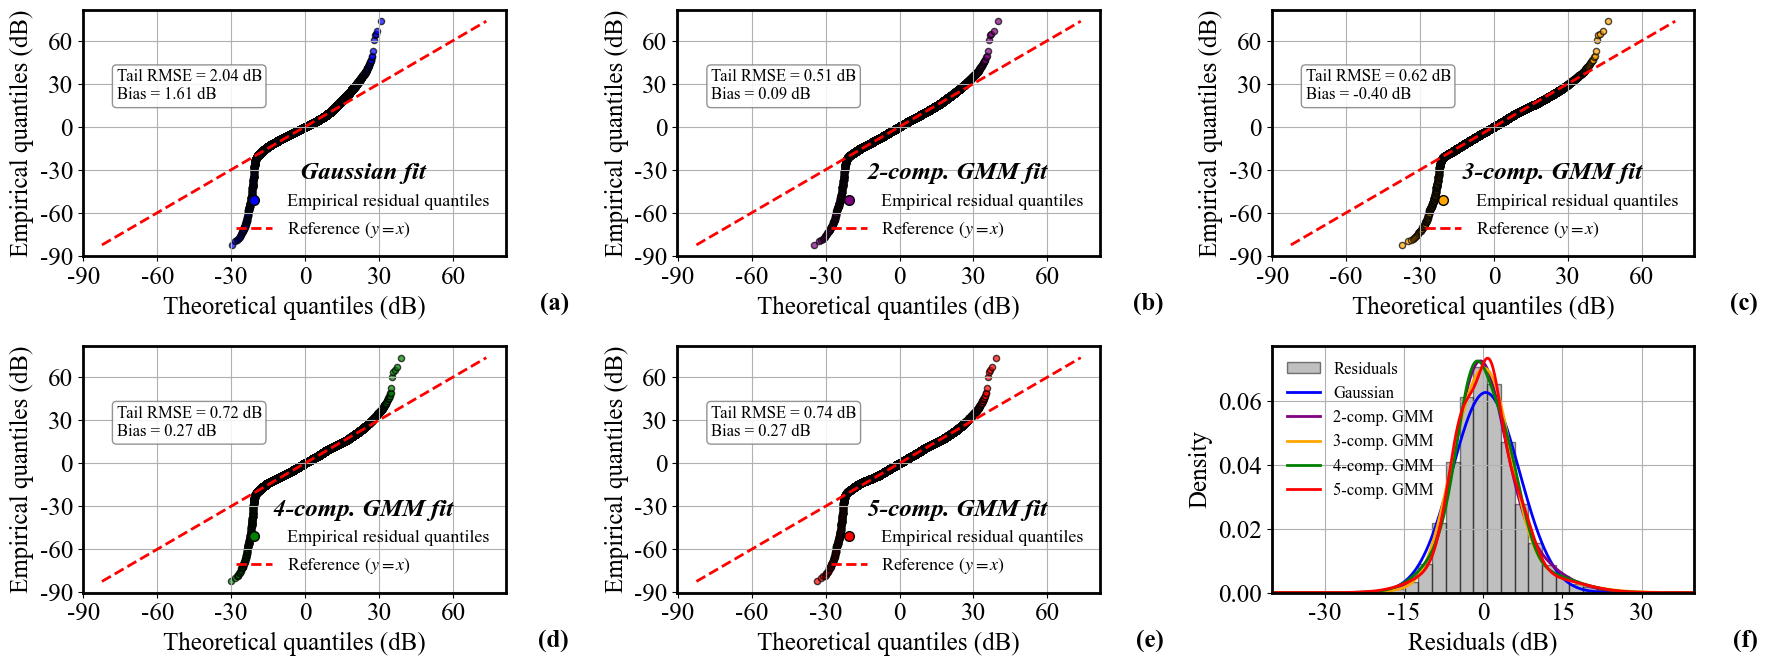

In [7]:
# GMM Q-Q plots + histogram

plt.rcParams.update({"font.size": 18, "axes.titlesize": 20, "axes.labelsize": 18, "legend.fontsize": 13,})

GMM_QQ_POINT_SIZE = 20
fig, axes = plt.subplots(2, 3, figsize=(18, 7))
axes = axes.flatten()

gmm_colors = ["blue", "purple", "orange", "green", "red"]

for i, gmm_model in enumerate(gmm_models):
    ax = axes[i]
    k = i + 1

    x_grid = np.linspace(res.min(), res.max(), 200000)
    cdf_grid = np.maximum.accumulate(gmm_cdf(x_grid, gmm_model))

    unique_cdf, unique_idx = np.unique(cdf_grid, return_index=True)
    unique_x = x_grid[unique_idx]

    ppf_func = interp1d(
        unique_cdf,
        unique_x,
        bounds_error=False,
        fill_value=(x_grid[0], x_grid[-1]),
    )
    theoretical_quantiles = ppf_func(probabilities)

    ax.scatter(
        theoretical_quantiles,
        sorted_residuals,
        s=GMM_QQ_POINT_SIZE,
        edgecolors="k",
        facecolor=gmm_colors[i],
        alpha=0.7,
    )

    min_val = min(theoretical_quantiles.min(), sorted_residuals.min())
    max_val = max(theoretical_quantiles.max(), sorted_residuals.max())
    ax.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=QQ_LINEWIDTH)

    ax.set_xlabel("Theoretical quantiles (dB)")
    ax.set_ylabel("Empirical quantiles (dB)")
    ax.grid(True)

    qq_legend(ax, gmm_display_names[k], gmm_colors[i])
    add_tail_error_text(ax, gmm_table_names[k], qq_tail_error_table)

    ax.text(
        1.15, -0.15, SUBPLOT_LABELS[i],
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontweight="bold",
        fontsize=18,
    )

ax6 = axes[5]
ax6.hist(res, bins=60, density=True, alpha=0.5, color="grey", edgecolor="black", label="Residuals")

x_vals = np.linspace(res.min(), res.max(), 1000)
for i, gmm_model in enumerate(gmm_models):
    k = i + 1
    density = np.exp(gmm_model.score_samples(x_vals.reshape(-1, 1)))
    ax6.plot(x_vals, density, color=gmm_colors[i], linewidth=QQ_LINEWIDTH, label=gmm_display_names[k])

ax6.set_xlabel("Residuals (dB)")
ax6.set_ylabel("Density")
ax6.legend(fontsize=12, frameon=False)
ax6.set_xlim(-40, 40)
ax6.grid(True)

ax6.text(
    1.15, -0.15, SUBPLOT_LABELS[5],
    transform=ax6.transAxes,
    ha="right",
    va="top",
    fontweight="bold",
    fontsize=18,
)

for i, ax in enumerate(axes):
    if i < 5:
        ax.xaxis.set_major_locator(MultipleLocator(30))
        ax.yaxis.set_major_locator(MultipleLocator(30))
    else:
        ax.xaxis.set_major_locator(MultipleLocator(15))
        ax.yaxis.set_major_locator(MultipleLocator(0.02))

    ax.tick_params(axis="both", which="major", labelsize=18)

    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_edgecolor("black")

plt.tight_layout()
# plt.savefig("Figures/gmm_qq_residual_plots.png", dpi=1000)
plt.show()

#### Print Distribution Parameters

In [8]:
# Print distribution parameters, including the BIC-selected GMM.

def print_group(title, params):
    bold_title = f"\033[1m {title} \033[0m"
    print(bold_title)
    for name, val in params:
        print(f"{name}: {val:.4f}")
    print("-" * 50)

print_group("Normal Distribution", [("Mean (μ)", loc_norm), ("Std (σ)", scale_norm)])
print_group("Skew-Normal Distribution", [("Shape", shape_sn), ("Location", loc_sn), ("Scale", scale_sn)])

print(f"\033[1m {best_gmm_display_name} (BIC-selected GMM) \033[0m")
for i in range(best_gmm.n_components):
    covs = best_gmm.covariances_
    if covs.ndim == 3:
        var = covs[i, 0, 0]
    elif covs.ndim == 2:
        var = covs[i, 0]
    else:
        var = covs[i]

    print(f"Component {i + 1}:")
    print(f"  Weight (π): {best_gmm.weights_[i]:.4f}")
    print(f"  Mean (μ):   {best_gmm.means_[i, 0]:.4f}")
    print(f"  Std (σ):    {np.sqrt(var):.4f}")
print("-" * 50)

print_group("Cauchy Distribution", [("Location", cauchy_params[0]), ("Scale", cauchy_params[1])])
print_group("t-Distribution", [("Degrees of Freedom (df)", df_t), ("Location", loc_t), ("Scale", scale_t)])

 Normal Distribution 
Mean (μ): 0.4968
Std (σ): 6.3766
--------------------------------------------------
 Skew-Normal Distribution 
Shape: 1.3165
Location: -4.6933
Scale: 8.2217
--------------------------------------------------
 3-comp. GMM (BIC-selected GMM) 
Component 1:
  Weight (π): 0.3335
  Mean (μ):   -3.9185
  Std (σ):    3.9303
Component 2:
  Weight (π): 0.1928
  Mean (μ):   4.5979
  Std (σ):    9.4887
Component 3:
  Weight (π): 0.4737
  Mean (μ):   1.9355
  Std (σ):    3.9587
--------------------------------------------------
 Cauchy Distribution 
Location: 0.0159
Scale: 3.4912
--------------------------------------------------
 t-Distribution 
Degrees of Freedom (df): 6.4389
Location: 0.2527
Scale: 5.2673
--------------------------------------------------


#### Diagnostic Subplots 2×3 (Normal, Skew, best GMM, Cauchy, t, Histogram)

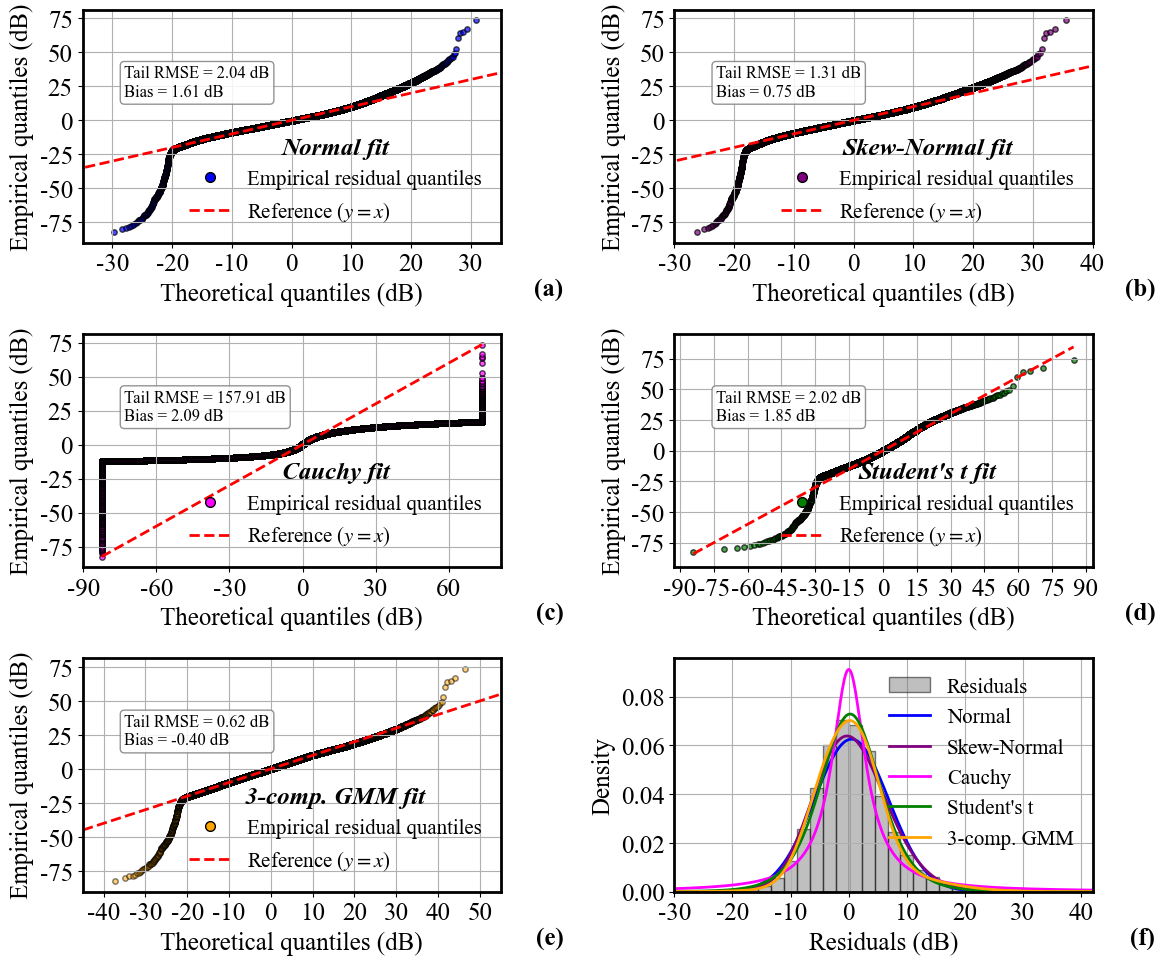

In [9]:
# Plot diagnostic subplots in a 3x2 grid.

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "legend.fontsize": 15,
})

DIAG_QQ_POINT_SIZE = 15
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

def manual_qq_plot(distribution, display_name, table_name, ax, color="blue"):
    theoretical_quantiles = distribution.ppf(probabilities)

    ax.scatter(
        theoretical_quantiles,
        sorted_residuals,
        s=DIAG_QQ_POINT_SIZE,
        edgecolors="k",
        facecolor=color,
        alpha=0.7,
    )

    min_val = min(theoretical_quantiles.min(), sorted_residuals.min())
    max_val = max(theoretical_quantiles.max(), sorted_residuals.max())
    ax.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=QQ_LINEWIDTH)

    ax.set_xlabel("Theoretical quantiles (dB)")
    ax.set_ylabel("Empirical quantiles (dB)")
    ax.grid(True)

    qq_legend(ax, display_name, color)
    add_tail_error_text(ax, table_name, qq_tail_error_table, pos=(0.1, 0.76))

# 1) Q-Q Plot (Normal)
manual_qq_plot(normal_dist, "Normal", "Normal", axes[0], color="blue")
axes[0].text(1.15, -0.15, SUBPLOT_LABELS[0], transform=axes[0].transAxes, ha="right", va="top", fontweight="bold", fontsize=18)
axes[0].set_xlim(-35, 35)

# 2) Q-Q Plot (Skew-Normal)
manual_qq_plot(skew_dist, "Skew-Normal", "SkewNormal", axes[1], color="purple")
axes[1].text(1.15, -0.15, SUBPLOT_LABELS[1], transform=axes[1].transAxes, ha="right", va="top", fontweight="bold", fontsize=18)
axes[1].set_xlim(-30, 40)

# 3) Q-Q Plot (Cauchy)
lower_bound = res.min()
upper_bound = res.max()
theoretical_quantiles = cauchy_dist.ppf(probabilities)
theoretical_quantiles_clipped = np.clip(theoretical_quantiles, lower_bound, upper_bound)

axes[2].scatter(
    theoretical_quantiles_clipped,
    sorted_residuals,
    s=DIAG_QQ_POINT_SIZE,
    edgecolors="k",
    facecolor="magenta",
    alpha=0.7,
)
axes[2].plot([lower_bound, upper_bound], [lower_bound, upper_bound], "r--", linewidth=QQ_LINEWIDTH)
axes[2].set_xlabel("Theoretical quantiles (dB)")
axes[2].set_ylabel("Empirical quantiles (dB)")
axes[2].grid(True)
qq_legend(axes[2], "Cauchy", "magenta")
add_tail_error_text(axes[2], "Cauchy", qq_tail_error_table, pos=(0.1, 0.76))
axes[2].text(1.15, -0.15, SUBPLOT_LABELS[2], transform=axes[2].transAxes, ha="right", va="top", fontweight="bold", fontsize=18)

# 4) Q-Q Plot (Student's t)
manual_qq_plot(t_dist, "Student's t", "StudentT", axes[3], color="green")
axes[3].text(1.15, -0.15, SUBPLOT_LABELS[3], transform=axes[3].transAxes, ha="right", va="top", fontweight="bold", fontsize=18)
axes[3].set_ylim(-95, 95)

# 5) Q-Q Plot (BIC-selected GMM)
x_grid = np.linspace(res.min(), res.max(), 200000)
cdf_grid = np.maximum.accumulate(gmm_cdf(x_grid, best_gmm))
unique_cdf, unique_indices = np.unique(cdf_grid, return_index=True)
unique_x = x_grid[unique_indices]
ppf_func = interp1d(unique_cdf, unique_x, bounds_error=False, fill_value=(x_grid[0], x_grid[-1]))
theoretical_gmm_quantiles = ppf_func(probabilities)

axes[4].scatter(
    theoretical_gmm_quantiles,
    sorted_residuals,
    s=DIAG_QQ_POINT_SIZE,
    edgecolors="k",
    facecolor="orange",
    alpha=0.5,
)
min_val = min(theoretical_gmm_quantiles.min(), sorted_residuals.min())
max_val = max(theoretical_gmm_quantiles.max(), sorted_residuals.max())
axes[4].plot([min_val, max_val], [min_val, max_val], "r--", linewidth=QQ_LINEWIDTH)
axes[4].set_xlabel("Theoretical quantiles (dB)")
axes[4].set_ylabel("Empirical quantiles (dB)")
axes[4].grid(True)
qq_legend(axes[4], best_gmm_display_name, "orange")
add_tail_error_text(axes[4], best_gmm_table_name, qq_tail_error_table, pos=(0.1, 0.76))
axes[4].text(1.15, -0.15, SUBPLOT_LABELS[4], transform=axes[4].transAxes, ha="right", va="top", fontweight="bold", fontsize=18)
axes[4].set_xlim(-45, 55)

# 6) Residuals Histogram with Fitted Densities
axes[5].hist(res, bins=70, density=True, alpha=0.5, color="grey", edgecolor="black", label="Residuals")

x_vals = np.linspace(res.min(), res.max(), 1000)
axes[5].plot(x_vals, normal_dist.pdf(x_vals), label="Normal", color="blue", linewidth=QQ_LINEWIDTH)
axes[5].plot(x_vals, skew_dist.pdf(x_vals), label="Skew-Normal", color="purple", linewidth=QQ_LINEWIDTH)
axes[5].plot(x_vals, cauchy_dist.pdf(x_vals), label="Cauchy", color="magenta", linewidth=QQ_LINEWIDTH)
axes[5].plot(x_vals, t_dist.pdf(x_vals), label="Student's t", color="green", linewidth=QQ_LINEWIDTH)

gmm_density = np.exp(best_gmm.score_samples(x_vals.reshape(-1, 1)))
axes[5].plot(x_vals, gmm_density, label=best_gmm_display_name, color="orange", linewidth=QQ_LINEWIDTH)

axes[5].set_xlabel("Residuals (dB)")
axes[5].set_ylabel("Density")
axes[5].legend(fontsize=15, frameon=False)
axes[5].grid(True)
axes[5].set_xlim(-30, 42)
axes[5].text(1.15, -0.15, SUBPLOT_LABELS[5], transform=axes[5].transAxes, ha="right", va="top", fontweight="bold", fontsize=18)

# Tick interval adjustments
axes[0].xaxis.set_major_locator(MultipleLocator(10))
axes[0].yaxis.set_major_locator(MultipleLocator(25))

axes[1].xaxis.set_major_locator(MultipleLocator(10))
axes[1].yaxis.set_major_locator(MultipleLocator(25))

axes[2].xaxis.set_major_locator(MultipleLocator(30))
axes[2].yaxis.set_major_locator(MultipleLocator(25))

axes[3].xaxis.set_major_locator(MultipleLocator(15))
axes[3].yaxis.set_major_locator(MultipleLocator(25))

axes[4].xaxis.set_major_locator(MultipleLocator(10))
axes[4].yaxis.set_major_locator(MultipleLocator(25))

axes[5].xaxis.set_major_locator(MultipleLocator(10))
axes[5].yaxis.set_major_locator(MultipleLocator(0.02))

for ax in axes:
    ax.tick_params(axis="both", which="major", labelsize=18)

    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_edgecolor("black")

plt.tight_layout()
# plt.savefig("Figures/qq_residual_plots.png", dpi=1000)
plt.show()